In [74]:
import typing, importlib, numpy as np, jax, jax.numpy as jnp, matplotlib.pyplot as plt, optax, tqdm

In [73]:
import metanet, simulationMetanet, persistentExitationSimulation
importlib.reload(metanet)
importlib.reload(simulationMetanet)
importlib.reload(persistentExitationSimulation)

<module 'persistentExitationSimulation' from '/home/pesim/uni/thesis/persistentExitationSimulation.py'>

In [75]:
traj_true, p_true, boundaries, init_stat = persistentExitationSimulation.simulate_example()

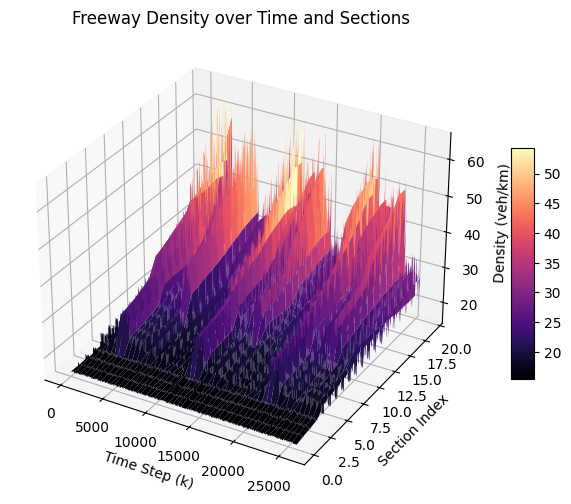

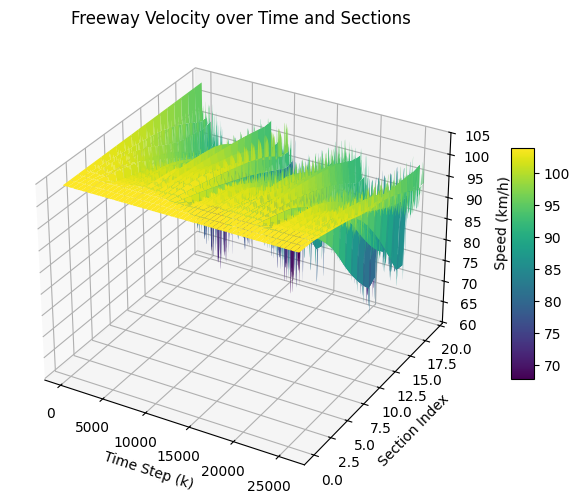

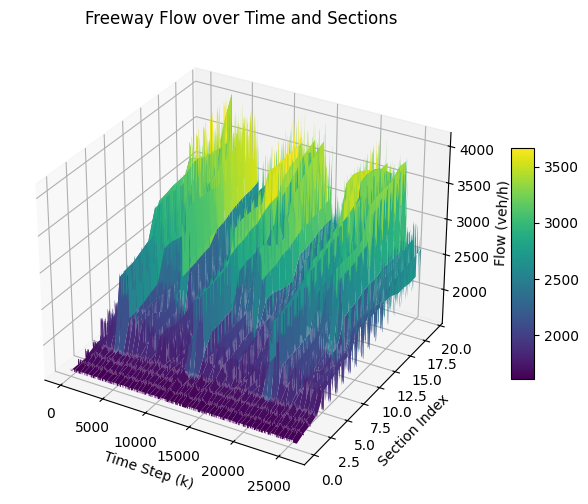

In [76]:
simulationMetanet.plot_trajectories(traj_true, N=20,K=25920)

Generating ground truth simulation data...

Starting parameter identification...


Loss: 0.5899 | Param Err: 0.0000 | Var Rho: 0.386 | Var V: 8.406: 100%|██████████| 1000/1000 [01:44<00:00,  9.57it/s]
/tmp/ipykernel_21615/689921775.py:207: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')  # Log scale is usually best to visualize parameter convergence



Identified METANET Parameters vs True Parameters:
           T: 0.0028 	(True: 0.0028) (FROZEN)
           L: [0.5 0.5 ... 0.5 0.5] 	(True: [0.5 0.5 ... 0.5 0.5]) (FROZEN)
     lambda_: [1. 1. ... 1. 1.] 	(True: [1. 1. ... 1. 1.]) (FROZEN)
         tau: [0.02 0.02 ... 0.02 0.02] 	(True: [0.02 0.02 ... 0.02 0.02]) 
          nu: [60. 60. ... 60. 60.] 	(True: [60. 60. ... 60. 60.]) 
       kappa: [40. 40. ... 40. 40.] 	(True: [40. 40. ... 40. 40.]) 
       delta: [0.012 0.012 ... 0.012 0.012] 	(True: [0.012 0.012 ... 0.012 0.012]) 
       alpha: [1.8 1.8 ... 1.8 1.8] 	(True: [1.8 1.8 ... 1.8 1.8]) 
  critical_density: [80. 80. ... 80. 80.] 	(True: [80. 80. ... 80. 80.]) 
  free_flow_speed: [120. 120. ... 120. 120.] 	(True: [120. 120. ... 120. 120.]) 

Learned Error Covariances (Variances):
  Density (rho) variance : 0.3679
  Speed (v) variance     : 8.0036


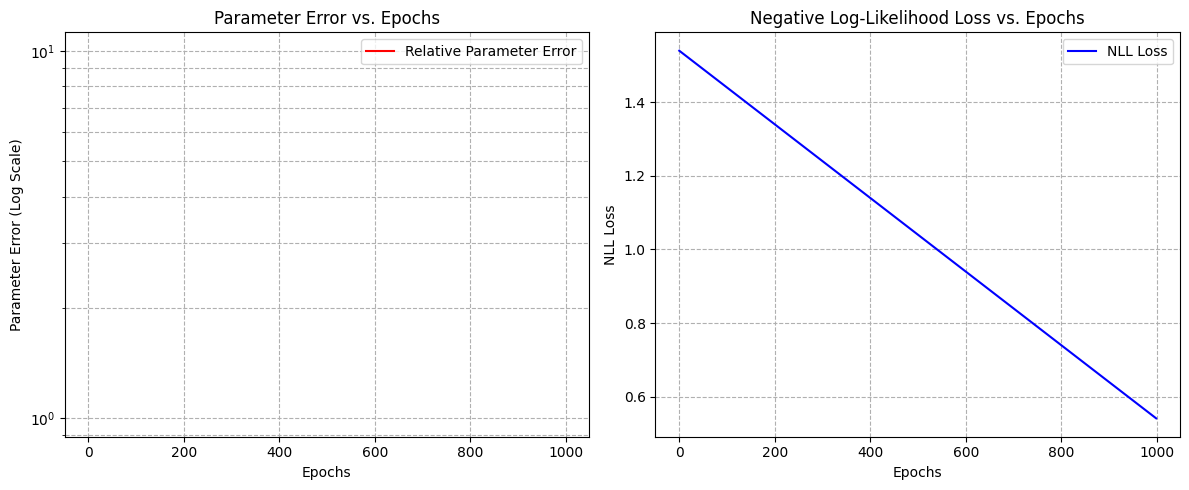

In [ ]:
class LearningParams(typing.NamedTuple):
    metanet: metanet.NetworkParameters
    log_vars: jax.Array

def calc_param_error(params, p_true, mask):
    """
    Calculates the Relative Mean Squared Error between predicted and true parameters.
    Only considers trainable parameters defined by the mask.
    """
    total_error = 0.0
    
    # Iterate over all fields in the metanet parameters
    for field in params.metanet._fields:
        p_pred = getattr(params.metanet, field)
        p_tgt = getattr(p_true, field)
        m = getattr(mask.metanet, field)
        
        # Calculate relative error: ((pred - true) / true)^2
        # Adding 1e-8 to avoid division by zero
        rel_diff = (p_pred - p_tgt) / (p_tgt + 1e-8)
        
        # Multiply by mask to ignore frozen parameters, and sum the array
        error_term = jnp.sum((rel_diff ** 2) * m)
        total_error += error_term
        
    return total_error

def nll_loss(params: LearningParams, traj_true: metanet.SimulationTrajectory, initial_state: metanet.NetworkState, boundaries: metanet.BoundarySequence):
    """
    Calculates the Negative Log-Likelihood loss.
    
    params: LearningParams containing METANET parameters and error variances
    traj_true: Ground truth trajectory data
    initial_state: Initial state of the network
    boundaries: Boundary conditions for the simulation
    """
    model_params = params.metanet
    log_vars = params.log_vars 
    
    # 1. Simulate trajectories using the current METANET parameters
    traj_pred = metanet.rollout_simulation(initial_state, boundaries, model_params)
    
    # 2. Compute errors between predicted and true trajectories
    error_rho = traj_pred.density - traj_true.density
    error_v   = traj_pred.speed - traj_true.speed
    
    # 3. Calculate Negative Log-Likelihood assuming Gaussian errors
    var_rho = jnp.exp(log_vars[0])
    var_v   = jnp.exp(log_vars[1])
    
    n = traj_true.density.size  # Total number of data points
    
    loss_rho = 0.5 * log_vars[0] + 0.5 * (error_rho**2).mean() / var_rho
    loss_v   = 0.5 * log_vars[1] + 0.5 * (error_v**2).mean() / var_v
    
    total_loss = loss_rho + loss_v
    
    return total_loss

# ==========================================
# 2. OPTIMIZATION LOOP SETUP
# ==========================================

K = 360 * 2 + 180  # 900 steps

print("Generating ground truth simulation data...")
traj_true, p_true, boundaries, init_stat = simulationMetanet.simulate_example()

# --- Initial parameter guess (small random perturbation around truth) ---
d = 0.  # ±5 % deviation
def perturb(key, true_val):
    return jax.random.uniform(
        key, true_val.shape,
        minval=(1 - d) * true_val,
        maxval=(1 + d) * true_val,
    )

keys = jax.random.split(jax.random.PRNGKey(42), 7)
initial_metanet_params = metanet.NetworkParameters(
    tau              = perturb(keys[0], p_true.tau),
    free_flow_speed  = perturb(keys[1], p_true.free_flow_speed),
    kappa            = perturb(keys[2], p_true.kappa),          # fixed: was using free_flow_speed bounds
    nu               = perturb(keys[3], p_true.nu),
    critical_density = perturb(keys[4], p_true.critical_density),
    alpha            = perturb(keys[5], p_true.alpha),
    delta            = perturb(keys[6], p_true.delta),
    L                = p_true.L,        # FROZEN
    lambda_          = p_true.lambda_,  # FROZEN
    T                = p_true.T,        # FROZEN
)

frac = traj_true.flow.sum() / traj_true.speed.sum()
initial_params = LearningParams(
    metanet  = initial_metanet_params,
    log_vars = jnp.array([jnp.log(1), jnp.log(1 * frac)]),
)


mask = LearningParams(
        metanet=metanet.NetworkParameters(
            tau=jnp.ones_like(p_true.tau),
            free_flow_speed=jnp.ones_like(p_true.free_flow_speed),
            kappa=jnp.ones_like(p_true.kappa),
            nu=jnp.ones_like(p_true.nu),
            critical_density=jnp.ones_like(p_true.critical_density),
            alpha=jnp.ones_like(p_true.alpha),
            delta=jnp.ones_like(p_true.delta),
            L=jnp.zeros_like(p_true.L),             # FROZEN
            lambda_=jnp.zeros_like(p_true.lambda_), # FROZEN
            T=0              # FROZEN
        ),
        log_vars=jnp.ones_like(initial_params.log_vars)
    )

# Setup Optax Optimizer using optax.masked
# This automatically applies updates ONLY where the mask is True.
learning_rate = 1e-3
optimizer = optax.adam(learning_rate)

opt_state = optimizer.init(initial_params)

# Define a JIT-compiled update step for speed
@jax.jit
def update_step(params, opt_state, traj_true, initial_state, boundaries):
    # value_and_grad computes both the loss and the gradients of the PyTree
    loss, grads = jax.value_and_grad(nll_loss)(params, traj_true, initial_state, boundaries)
        
        # SAFELY zero out frozen gradients using jnp.where. 
        # This completely immunizes your frozen parameters against NaNs.
    grads = jax.tree_util.tree_map(
        lambda g, m: jnp.where(m == 1.0, g, 0.0),
        grads, 
        mask
    )
    
    # Calculate parameter updates based on the cleaned gradients
    updates, opt_state = optimizer.update(grads, opt_state, params)
    
    # Apply updates to parameters
    new_params = optax.apply_updates(params, updates)
    
    return new_params, opt_state, loss


# ==========================================
# 3. TRAINING LOOP
# ==========================================
num_epochs = 1000
params = initial_params

# Initialize lists to store the history for plotting
nll_loss_history = []
param_error_history = []

print("\nStarting parameter identification...")
pbar = tqdm.tqdm(range(num_epochs))
for epoch in pbar:
    # Perform optimization step
    params, opt_state, loss = update_step(params, opt_state, traj_true, init_stat, boundaries)
    
    # Calculate parameter error against ground truth (p_true)
    p_err = calc_param_error(params, p_true, mask)
    
    # Store metrics
    nll_loss_history.append(float(loss))
    param_error_history.append(float(p_err))
    
    # Update progress bar every 50 epochs
    if epoch % 50 == 0:
        var_rho = jnp.exp(params.log_vars[0])
        var_v = jnp.exp(params.log_vars[1])
        pbar.set_description(f"Loss: {loss:.4f} | Param Err: {p_err:.4f} | Var Rho: {var_rho:.3f} | Var V: {var_v:.3f}")

print("\nIdentified METANET Parameters vs True Parameters:")

# Pretty print the comparison
for field in params.metanet._fields:
    learned_val = getattr(params.metanet, field)
    true_val = getattr(p_true, field)
    frozen_str = "(FROZEN)" if field in ['L', 'lambda_', 'T'] else ""
    
    if jnp.size(learned_val) == 1:
        l_str = f"{float(jnp.squeeze(learned_val)):.4f}"
        t_str = f"{float(jnp.squeeze(true_val)):.4f}"
    else:
        with np.printoptions(precision=4, suppress=True, edgeitems=2, threshold=5):
            l_str = f"{np.array(learned_val)}"
            t_str = f"{np.array(true_val)}"
        
    print(f"  {field:>10}: {l_str} \t(True: {t_str}) {frozen_str}")
    
print("\nLearned Error Covariances (Variances):")
print(f"  Density (rho) variance : {float(jnp.exp(params.log_vars[0])):.4f}")
print(f"  Speed (v) variance     : {float(jnp.exp(params.log_vars[1])):.4f}")

# ==========================================
# 4. PLOT THE RESULTS
# ==========================================
plt.figure(figsize=(12, 5))

# Plot 1: The real vs predicted parameter error (Relative MSE)
plt.subplot(1, 2, 1)
plt.plot(range(num_epochs), param_error_history, label='Relative Parameter Error', color='red')
plt.xlabel('Epochs')
plt.ylabel('Parameter Error (Log Scale)')
plt.title('Parameter Error vs. Epochs')
plt.yscale('log')  # Log scale is usually best to visualize parameter convergence
plt.grid(True, which="both", ls="--")
plt.legend()

# Plot 2: The standard NLL loss
plt.subplot(1, 2, 2)
plt.plot(range(num_epochs), nll_loss_history, label='NLL Loss', color='blue')
plt.xlabel('Epochs')
plt.ylabel('NLL Loss')
plt.title('Negative Log-Likelihood Loss vs. Epochs')
plt.grid(True, which="both", ls="--")
plt.legend()

plt.tight_layout()
plt.show()




In [59]:
traj_new = metanet.rollout_simulation(init_stat, boundaries, params.metanet)

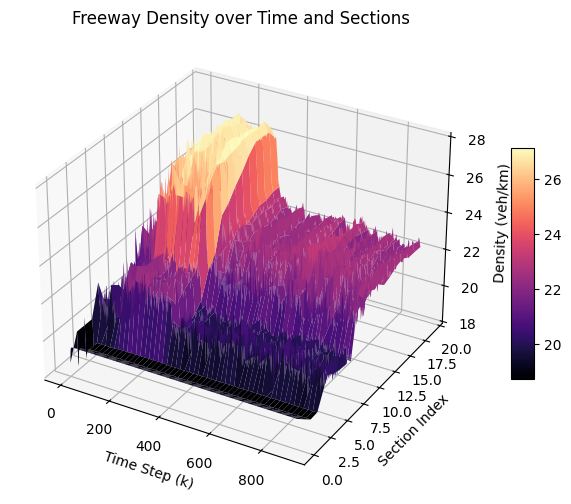

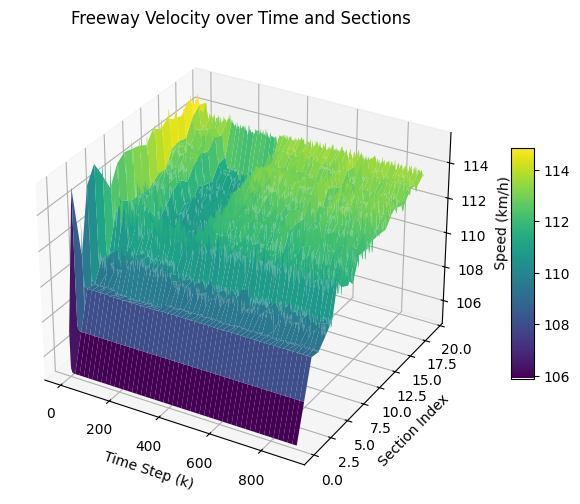

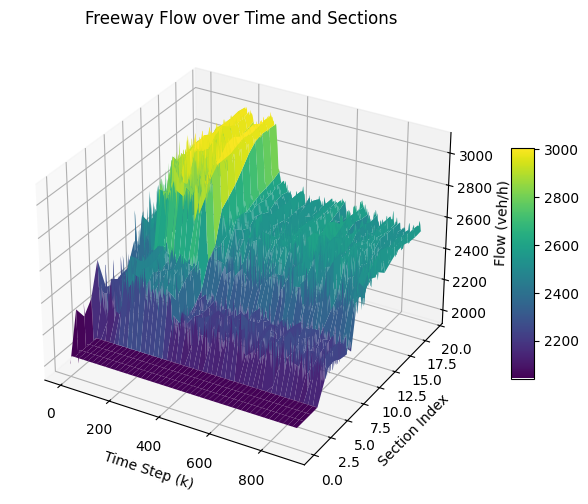

In [60]:
simulationMetanet.plot_trajectories(traj_new, N=20, K=900)

In [41]:
print(params.metanet)

NetworkParameters(T=Array(nan, dtype=float32), L=Array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan], dtype=float32), lambda_=Array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan], dtype=float32), tau=Array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan], dtype=float32), nu=Array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan], dtype=float32), kappa=Array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan], dtype=float32), delta=Array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan], dtype=float32), alpha=Array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan], dtype=float32), c